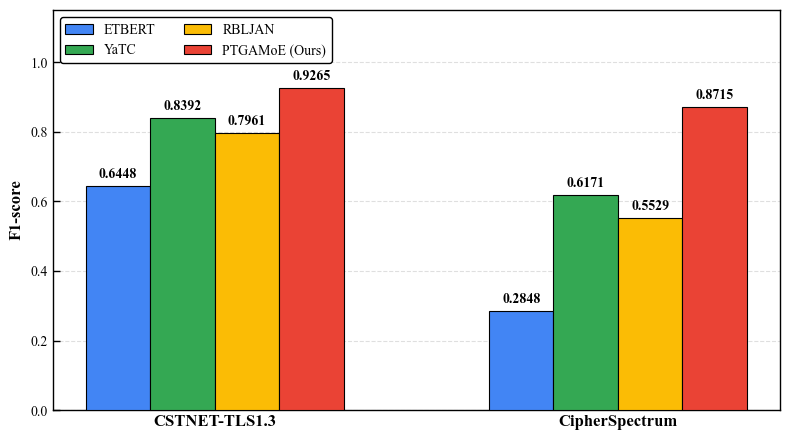

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 风格设置：IEEE TIFS 严谨学术风
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["axes.unicode_minus"] = False

# 2. 数据准备
data = {
    'Dataset': ['CSTNET-TLS1.3', 'CipherSpectrum'],
    'ETBERT': [0.6448, 0.2848],
    'YaTC': [0.8392, 0.6171],
    'RBLJAN': [0.7961, 0.5529],
    'PTGAMoE (Ours)': [0.9265, 0.8715]
}

df_perf = pd.DataFrame(data)
methods = ['ETBERT', 'YaTC', 'RBLJAN', 'PTGAMoE (Ours)']

# 3. 配色方案：Chrome 经典四色
# 顺序：蓝 (ETBERT), 绿 (YaTC), 黄 (RBLJAN), 红 (Ours)
chrome_colors = ['#4285F4', '#34A853', '#FBBC05', '#EA4335']

def draw_chrome_style_performance():
    # 稍微拉宽画布，给柱子留出“呼吸”空间
    fig, ax = plt.subplots(figsize=(8, 4.5))

    x = np.arange(len(df_perf['Dataset']))  
    width = 0.16  # 缩减柱子宽度，使其看起来更利落 (原 0.18 -> 0.16)
    
    # 4. 绘制分组柱状图
    for i, method in enumerate(methods):
        # 计算每个柱子的偏移位置，确保整体居中
        pos = x - (len(methods) * width) / 2 + (i + 0.5) * width
        
        bars = ax.bar(pos, df_perf[method], width, 
                      label=method, 
                      color=chrome_colors[i], 
                      edgecolor='black', 
                      linewidth=0.8,
                      zorder=3)
        
        # 5. 增强数值标注：加大字号 (fontsize=10), 提升可读性
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.015,
                    f'{height:.4f}', ha='center', va='bottom', 
                    fontsize=10, fontweight='bold', family='serif')

    # 6. 坐标轴与严谨性
    ax.set_ylabel('F1-score', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(df_perf['Dataset'], fontsize=12, fontweight='bold')
    
    # 锁定 Y 轴，为数值标注留出 0.15 的缓冲区
    ax.set_ylim(0, 1.15) 
    ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
    
    # 7. 细节美化
    for spine in ax.spines.values():
        spine.set_linewidth(1.0) # 稍微加厚边框
        spine.set_color('black')
    
    ax.tick_params(direction='in', length=5, width=1.0)
    
    # 8. 图例设置
    # 为了不遮挡数值，将图例放在左上角或右上角
    ax.legend(loc='upper left', fontsize=10, frameon=True, 
              edgecolor='black', framealpha=1.0, ncol=2) # ncol=2 节省纵向空间

    # 辅助线：淡淡的水平线有助于横向对比
    ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)

    plt.tight_layout()
    # plt.savefig("Performance_Chrome_Style.pdf", bbox_inches='tight')
    plt.show()

# 执行
draw_chrome_style_performance()